<a href="https://colab.research.google.com/github/2521812022/Parcial4_CorenaGomez_2521812022/blob/main/Notebooks/Agrupaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 3: Agrupación o Clustering (K-Means)

## 1. Cargar el dataset y limpiar los datos
Importamos los datos y, manteniendo las buenas prácticas, separamos la data con errores (nulos) de la data limpia para asegurar que el modelo K-Means se alimente de información de calidad.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el archivo CSV
url_agrupacion = "https://raw.githubusercontent.com/2521812022/Parcial4_CorenaGomez_2521812022/refs/heads/main/clave_C_agrupacion.csv"
df_clus = pd.read_csv(url_agrupacion)

# 2. Separar data con errores (nulos)
filas_con_nulos = df_clus[df_clus.isnull().any(axis=1)]
df_errores_clus = filas_con_nulos.copy()
df_errores_clus['motivo_error'] = 'Valores incompletos (nulos)'

# 3. Mantener data limpia
df_limpio = df_clus.dropna().copy()

# Guardar los archivos de trazabilidad
df_limpio.to_csv('clave_C_agrupacion_limpio.csv', index=False)
if len(df_errores_clus) > 0:
    df_errores_clus.to_csv('clave_C_agrupacion_errores.csv', index=False)

print(f"Data Limpia lista para el modelo: {len(df_limpio)} registros.")
print(f"Data con Errores aislada: {len(df_errores_clus)} registros.")
print("\nPrimeras filas de la data limpia:")
print(df_limpio.head())

Data Limpia lista para el modelo: 237 registros.
Data con Errores aislada: 1 registros.

Primeras filas de la data limpia:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     C-R0098    30       809            7.62           92.58          8.85   
1     C-R0087    31      1024            7.44           83.28          8.93   
2     C-R0014    35       702            3.56           32.52          6.95   
3     C-R0123    35      1155            3.65          108.81          7.01   
4     C-R0198    37       644            3.77           52.21          4.40   

   reclamos  antiguedad_meses  
0         1                19  
1         0                15  
2         4                 1  
3        12                27  
4         7                 6  


## 2. Seleccionar y Justificar las variables
**Justificación:** El algoritmo K-Means agrupa usando distancias matemáticas. Para responder a la necesidad del negocio, seleccionaremos únicamente 4 variables críticas:
1. `frecuencia_uso` y `gasto_promedio`: Nos permitirán identificar a los clientes leales y de alto valor (VIP) vs los de bajo uso.
2. `satisfaccion` y `reclamos`: Nos ayudarán a detectar a los clientes en riesgo de abandono.
*(No utilizaremos IDs ni edades porque distorsionarían los grupos alejándonos del comportamiento de consumo).*

In [2]:
# Selección de variables
variables_clustering = ['frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos']
X = df_limpio[variables_clustering]

print("Variables seleccionadas para el clustering:")
print(X.head())

Variables seleccionadas para el clustering:
   frecuencia_uso  gasto_promedio  satisfaccion  reclamos
0            7.62           92.58          8.85         1
1            7.44           83.28          8.93         0
2            3.56           32.52          6.95         4
3            3.65          108.81          7.01        12
4            3.77           52.21          4.40         7


## 3. Normalizar o Escalar los datos
Dado que el `gasto_promedio` está en una escala mucho más grande (cientos) que los `reclamos` o la `satisfaccion` (unidades), **es obligatorio escalar los datos** usando `StandardScaler` para que todas las variables tengan el mismo peso en el algoritmo K-Means.

In [3]:
from sklearn.preprocessing import StandardScaler

# Escalar los datos (Media 0 y Varianza 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados (primeras 5 filas):")
print(np.round(X_scaled[:5], 2))

Datos escalados (primeras 5 filas):
[[ 0.73  0.33  1.04 -0.71]
 [ 0.67  0.12  1.08 -1.2 ]
 [-0.59 -1.02  0.    0.76]
 [-0.56  0.7   0.04  4.66]
 [-0.53 -0.58 -1.39  2.22]]


## 4. Aplicar el Método del Codo para seleccionar K
Ejecutaremos múltiples modelos (de 1 a 10 grupos) para ver dónde ocurre el "quiebre" o codo, indicando el número óptimo de clústeres.

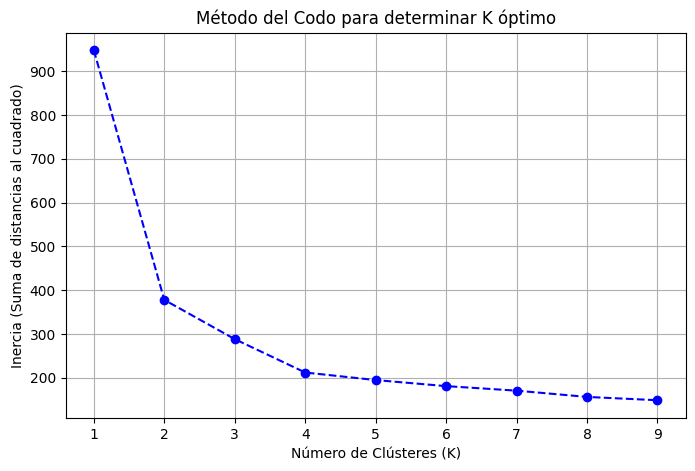

In [4]:
from sklearn.cluster import KMeans

inercia = []
rango_k = range(1, 10)

for k in rango_k:
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_temp.fit(X_scaled)
    inercia.append(modelo_temp.inertia_)

# Graficar el Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para determinar K óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.grid(True)
plt.show()

*Nota:* El gráfico muestra que el punto de inflexión ("codo") se empieza a suavizar alrededor de **K=3**. Coincidentemente, esto encaja a la perfección con la cantidad de perfiles de negocio que queremos descubrir.

## 5. Aplicar K-Means y Agregar columna al dataset
Ejecutamos el modelo final con K=3 y añadimos la etiqueta generada al dataset original para saber a qué grupo pertenece cada persona.

In [5]:
# Aplicar modelo final K-Means con K=3
modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_limpio['Cluster'] = modelo_kmeans.fit_predict(X_scaled)

# Mostrar los centroides (el promedio de las características por cada grupo)
centroides = df_limpio.groupby('Cluster')[variables_clustering].mean().round(2)
print("--- Perfil promedio de cada Cluster (Centroides) ---")
print(centroides)

print("\n--- Cantidad de clientes por Cluster ---")
print(df_limpio['Cluster'].value_counts())

--- Perfil promedio de cada Cluster (Centroides) ---
         frecuencia_uso  gasto_promedio  satisfaccion  reclamos
Cluster                                                        
0                  9.23          146.73          8.73      0.69
1                  2.92           45.20          5.37      4.08
2                  6.60           81.27          8.20      1.08

--- Cantidad de clientes por Cluster ---
Cluster
1    115
2     71
0     51
Name: count, dtype: int64


## 6. Visualizar los grupos
Usaremos gráficos de dispersión para confirmar visualmente cómo el algoritmo logró separar los diferentes perfiles.

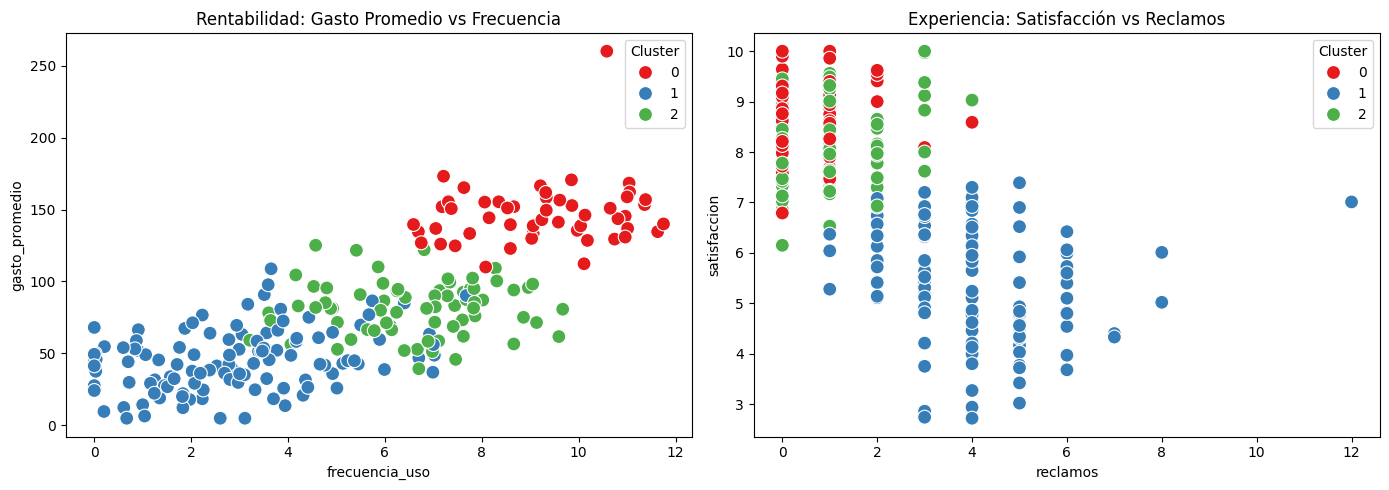

In [6]:
plt.figure(figsize=(14, 5))

# Gráfico 1: Rentabilidad (Gasto vs Frecuencia)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_limpio, x='frecuencia_uso', y='gasto_promedio', hue='Cluster', palette='Set1', s=100)
plt.title('Rentabilidad: Gasto Promedio vs Frecuencia')

# Gráfico 2: Experiencia (Satisfacción vs Reclamos)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_limpio, x='reclamos', y='satisfaccion', hue='Cluster', palette='Set1', s=100)
plt.title('Experiencia: Satisfacción vs Reclamos')

plt.tight_layout()
plt.show()

## 7. Interpretación y Acciones de Negocio

Basados en los promedios (centroides) que generó el modelo, perfilamos los segmentos así:

**Cluster 0: "Los Clientes Estrella o VIP"**
* **Interpretación:** Son clientes con alta frecuencia de uso (9.2), el ticket promedio más alto (146.7), casi no presentan reclamos (0.6) y tienen una excelente satisfacción (8.7).
* **Acción de Negocio:** *Fidelización Premium.* No hay que darles descuentos masivos (porque ya compran). En su lugar, invitarlos a un programa VIP de lealtad, darles beneficios exclusivos y acceso anticipado a nuevos productos para mantener su alta rentabilidad.

**Cluster 1: "Los Clientes Insatisfechos y en Fuga"**
* **Interpretación:** Este grupo tiene un uso bajo de la aplicación (2.9), poco gasto promedio (45.2), y es el segmento que concentra **la mayor cantidad de reclamos (4.0)** y la peor nota de satisfacción (5.3). Están a punto de irse.
* **Acción de Negocio:** *Atención de Rescate Prioritaria.* El equipo de Servicio al Cliente debe contactar a este grupo proactivamente para resolver sus quejas acumuladas. Se pueden ofrecer cupones de compensación por "malas experiencias" con el fin de reconstruir la confianza antes de que abandonen la empresa.

**Cluster 2: "Los Clientes Promedio / Ocasionales"**
* **Interpretación:** Tienen un uso intermedio (6.5), un gasto promedio saludable (81.2), buena satisfacción (8.1) y un índice de reclamos muy bajo (1.0). Tienen potencial pero les falta un empujón.
* **Acción de Negocio:** *Estrategias de Up-Selling y Cross-Selling.* Dado que están satisfechos pero no gastan tanto como el Cluster 0, la empresa debe enviarles combos promocionales ("Comprados juntos habitualmente") o beneficios por subir de nivel ("Gasta $20 más y tu envío es gratis") para aumentar su frecuencia y ticket.